In [1]:
### IMPORTS
import numpy as np
from scipy import stats
import torch
import swyft
import os
import pickle
from scipy.linalg import solve_triangular

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib import rc
import matplotlib as mpl

use_latex = True
if use_latex:
    os.environ['PATH'] = "/home/abellan/texlive/2025/bin/x86_64-linux:" + os.environ['PATH']
    rc('text', usetex=True)
    rc('font', **{'family': 'serif', 'serif': ['cmr10']})
    mpl.rcParams['text.latex.preamble'] = r'\usepackage{{amsmath}}'

DEVICE = 'gpu' if torch.cuda.is_available() else 'cpu'  

/home/awernersson/venvs/tmnre/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
### Import from merlin
from merlin.config import load_config, populate_train_dir
from merlin.priors import resolve_inference_params
from merlin.preprocessing import preprocess_obs
from merlin.inference import predict_from_checkpoint
from merlin.network import Network
from merlin.io import load_array
from merlin.params import PARAM_LABELS, MCMC_KEY_MAP
from merlin.plotting import load_mcmc_overlay, mcmc_samples_for
from merlin.swyft_patches import apply_patches

# Drops the 3-sigma credible band and restores color-driven (not cmap-filled)
# 2D contour lines in swyft.plot_corner — see merlin/swyft_patches.py.
apply_patches()

In [ ]:
### Load config
config_path = '../input/config_example.yaml'
config = load_config(config_path)

### Select which training run to plot — must already exist (created by merlin-train)
TRAIN_ID = 1   # ← change to the train_<N> you want to inspect
populate_train_dir(config, config_path, train_id=TRAIN_ID)
print(f"Plotting train_{TRAIN_ID}: {config['STORES']['checkpoint_path']}")

In [ ]:
obs = np.load(
        config["OBSERVATION"]["OBS"], allow_pickle=True
).item()

Nbin_z = config["AUX FILES"]["Nbin_z"]
N_spectra = Nbin_z*(2*Nbin_z+1)

ell_theory = load_array(config["AUX FILES"]["ell"])
N_ell = len(ell_theory)

In [5]:
WL_keys = [("SHE", "SHE", i, j)
    for i in range(1, Nbin_z + 1)
    for j in range(i, Nbin_z + 1)]

GG_keys = [("POS", "POS", i, j)
    for i in range(1, Nbin_z + 1)
    for j in range(i, Nbin_z + 1)]

GGL_keys = [("POS", "SHE", i, j)
    for i in range(1, Nbin_z + 1)
    for j in range(1, Nbin_z + 1)]

n_WL = len(WL_keys)
n_GGL = len(GGL_keys)
n_GC = len(GG_keys)

offset_WL = 0
offset_GGL = n_WL
offset_GC = n_WL + n_GGL

cells_sim = obs['C_ells']
noise_sim = obs['noise']

#idx_sim = 3000
#cells_sim = store[idx_sim]['C_ells']
#noise_sim = store[idx_sim]['noise']

cells_2d = cells_sim.reshape(N_spectra, N_ell).T
noise_2d = noise_sim.reshape(N_spectra, N_ell).T
ells = ell_theory

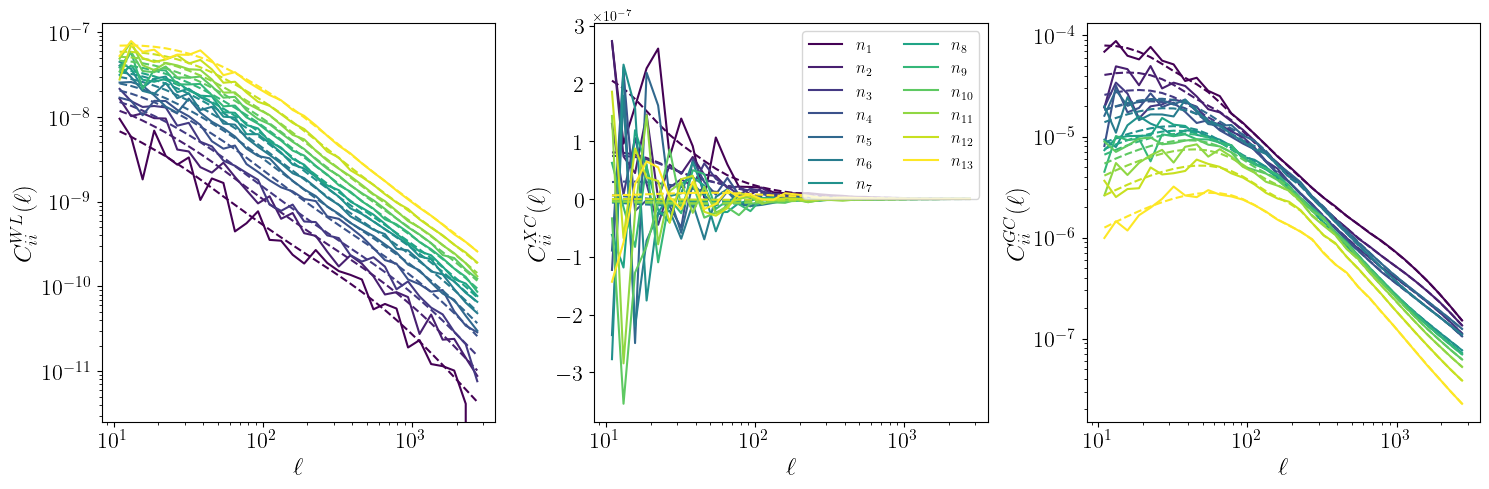

In [6]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

cmap = plt.cm.viridis
colors = cmap(np.linspace(0, 1, Nbin_z))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))  
plt.subplots_adjust(wspace=0)

for ax_idx, ax in enumerate(axes):
    for i in range(Nbin_z):
        ax.set_xscale('log')
        if ax_idx == 0:
            idx = i*Nbin_z - i*(i-1)//2
            spec_index = offset_WL + idx
            ax.set_ylabel(r'$C^{WL}_{ii} (\ell)$', fontsize=18)
            ax.set_yscale('log')
        elif ax_idx == 1:
            idx = i*Nbin_z + i
            spec_index = offset_GGL + idx
            ax.set_ylabel(r'$C^{XC}_{ii} (\ell)$', fontsize=18)
            ax.set_yscale('linear')
        else:
            idx = i*Nbin_z - i*(i-1)//2
            spec_index = offset_GC + idx
            ax.set_ylabel(r'$C^{GC}_{ii} (\ell)$', fontsize=18)
            ax.set_yscale('log')
        C_ells = cells_2d[:, spec_index]
        C_ells_noisy = cells_2d[:, spec_index] + noise_2d[:, spec_index]
        ax.plot(ells, C_ells, linestyle='--', color=colors[i])
        ax.plot(ells, C_ells_noisy, linestyle='-', color=colors[i],label=rf'$n_{{{i+1}}}$' if ax_idx == 1 else None)  

    ax.set_xlabel(r'$\ell$', fontsize=18)
    ax.tick_params(axis='both', which='major', labelsize=16)

axes[1].legend(loc='upper right', ncol=2, fontsize=12)

plt.tight_layout()
plt.show()
plt.close()

# Validate training

In [ ]:
### Architecture metadata (no weights needed yet) + PCA projection
param_names, param_indices = resolve_inference_params(config)
num_params_show = len(param_indices)
marginals = Network._get_marginals(num_params_show)

V_proj = load_array(config["PCA"]["SVD"])
print(f"Using {V_proj.shape[1]} PCA components")

In [ ]:
### Get predictions straight from the trained-network checkpoint — no retraining,
### no pickled predictions file needed.
import os

Lfid = np.load(config["OBSERVATION"]["LFID"])
obs_sample = preprocess_obs(obs, Lfid, config=config)

checkpoint_path = os.path.join(config["STORES"]["checkpoint_path"], "best.ckpt")
predictions = predict_from_checkpoint(checkpoint_path, V_proj, obs_sample, config)
print(f"Predictions computed from checkpoint: {checkpoint_path}")

In [ ]:
### MCMC overlay (optional — set MCMC_OVERLAY.chain_path in the config to enable)
chain_dict, weights = load_mcmc_overlay(config)
mcmc_samples = mcmc_samples_for(param_names, chain_dict, weights) if chain_dict is not None else None

if mcmc_samples is not None:
    mcmc_keys = [MCMC_KEY_MAP[name] for name in param_names]
    print(f"Loaded MCMC overlay from {config['MCMC_OVERLAY']['chain_path']}")
else:
    print("No MCMC_OVERLAY.chain_path configured — corner plot below will show SBI predictions only")

In [ ]:
%matplotlib inline
N_plot = num_params_show
fig, axes = plt.subplots(N_plot, N_plot, figsize=(9,9))
color_swyft='black'
color_mcmc='green'
color_fid = 'red'
fontsize_tick = 11

# corner plot with swyft predictions
plot_pars = [PARAM_LABELS.get(name, name) for name in param_names]
parnames = [f'z[{i}]' for i in range(N_plot)]
swyft.plot_corner(predictions, parnames,
                  color=color_swyft, fig=fig, bins=100, smooth=2, contours_1d=False)

if mcmc_samples is not None:
    # ---- MCMC overlay via getdist density estimates ----
    # Save swyft axis limits before drawing on top of them
    xlims = [axes[i, i].get_xlim() for i in range(N_plot)]
    ylims_diag = [axes[i, i].get_ylim() for i in range(N_plot)]
    ylims_off = {(j, i): axes[j, i].get_ylim() for i, j in marginals}
    xlims_off = {(j, i): axes[j, i].get_xlim() for i, j in marginals}

    for i in range(N_plot):
        # 1D marginals on diagonal
        density = mcmc_samples.get1DDensity(mcmc_keys[i])
        xs = np.linspace(*xlims[i], 500)
        ys = density.Prob(xs)
        if ys.max() > 0:
            ys = ys / ys.max() * ylims_diag[i][1]
        axes[i, i].plot(xs, ys, color=color_mcmc, lw=1.5)
        axes[i, i].set_xlim(xlims[i])
        axes[i, i].set_ylim(ylims_diag[i])

    for i, j in marginals:
        if xlims_off[(j, i)][0] == xlims_off[(j, i)][1] or ylims_off[(j, i)][0] == ylims_off[(j, i)][1]:
            # Degenerate (zero-width) swyft posterior on this panel — nothing
            # meaningful to overlay here.
            continue
        # 2D contours on off-diagonal
        density2d = mcmc_samples.get2DDensity(mcmc_keys[i], mcmc_keys[j], normalized=True)
        xs = np.linspace(*xlims_off[(j, i)], 200)
        ys = np.linspace(*ylims_off[(j, i)], 200)
        XX, YY = np.meshgrid(xs, ys)
        # NOT density2d.Prob(XX, YY) — installed getdist==1.4's Density2D.Prob
        # calls self.__call__(...) but never returns it (always gives None).
        # Call the (callable) density object directly instead, with the 1D
        # xs/ys and grid=True (not the meshgridded XX/YY) to get a proper
        # (len(xs), len(ys)) grid back — then transpose to match meshgrid's
        # (ny, nx) convention for ax.contour.
        ZZ = density2d(xs, ys, grid=True).T
        levels = sorted(density2d.getContourLevels([0.68, 0.95]))
        axes[j, i].contour(XX, YY, ZZ, levels=levels, colors=color_mcmc, linewidths=1.5)
        axes[j, i].set_xlim(xlims_off[(j, i)])
        axes[j, i].set_ylim(ylims_off[(j, i)])
    # ----------------------------------

for i in range(N_plot): 
    axes[i, i].axvline(obs['z'][param_indices[i]], color=color_fid, lw=1., linestyle='dashed')
    axes[i, i].minorticks_on()
    axes[i, i].tick_params(axis='both', which='major', direction="in", labelsize=fontsize_tick, rotation=45, size=4)
    axes[i, i].tick_params(axis='both', which='minor', direction="in", labelsize=fontsize_tick, rotation=45, size=2, left=False)
    
for i, j in marginals: 
    axes[j, i].axvline(obs['z'][param_indices[i]], color=color_fid, lw=1., linestyle='dashed')
    axes[j, i].axhline(obs['z'][param_indices[j]], color=color_fid, lw=1., linestyle='dashed')
    axes[j, i].minorticks_on()
    axes[j, i].tick_params(axis='both', which='major', direction="in", labelsize=fontsize_tick, rotation=45, size=4)
    axes[j, i].tick_params(axis='both', which='minor', direction="in", labelsize=fontsize_tick, rotation=45, size=2)
    
for i in range(N_plot):
    axes[N_plot-1, i].tick_params(axis='both', which='major', direction="in", labelsize=fontsize_tick, rotation=45, size=4)
    axes[N_plot-1, i].tick_params(axis='both', which='minor', direction="in", labelsize=fontsize_tick, rotation=45, size=2)
    axes[N_plot-1, i].set_xlabel(plot_pars[i], fontsize=13)
    axes[N_plot-1, i].minorticks_on()
for i in range(1, N_plot):
    axes[i, 0].set_ylabel(plot_pars[i], fontsize=13)
for i in range(1, N_plot):
    axes[i, 0].tick_params(axis='both', which='major', direction="in", labelsize=fontsize_tick, size=4)
    axes[i, 0].tick_params(axis='both', which='minor', direction="in", labelsize=fontsize_tick, rotation=45, size=2)
    axes[i, 0].minorticks_on()

for i, j in marginals:
    [x.set_linewidth(1.5) for x in axes[j, i].spines.values()]
for i in range(N_plot):
    [x.set_linewidth(1.5) for x in axes[i, i].spines.values()]

# updated legend
labels = ['\n MNRE, 40min (simulation) \n + 10mins (training)']
colors = [color_swyft]
alphas = [1.]
if mcmc_samples is not None:
    labels.append('\n MCMC')
    colors.append(color_mcmc)
    alphas.append(1.)
lines = [Line2D([0], [0], color=colors[i], alpha=alphas[i], linewidth=10, linestyle='-') 
         for i in range(len(labels))]
plt.legend(lines, labels, loc=(-2.0, 4.4), fontsize=15, frameon=False)

plt.savefig('corner_cosmo_merlin_vs_MCMC.pdf' if mcmc_samples is not None else 'corner_cosmo_merlin.pdf')
plt.show()